### Figures for paper

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

In [2]:
# Load data
# Update path to use new data directory structure
data_dir = os.path.join(os.getcwd(), "Data")

# tight to naive (noiseless, QAOA P=3)
# loaded_data_path = os.path.join(data_dir, "Noisy_Results_P4_random_init_20_graphs.npz")
# Prefer the re-run that includes constraint-violation distributions; fall back to the original file.
loaded_data_path = os.path.join(data_dir, "Noisy_Results_P1_random_init_10_graphs_cvar_violations.npz")
if not os.path.exists(loaded_data_path):
    loaded_data_path = os.path.join(data_dir, "Noisy_Results_P1_random_init_10_graphs_cvar.npz")
loaded_data = np.load(loaded_data_path)


QUBO_EXP_VALS = loaded_data['QUBO_EXP_VALS']
QUBO_FEASIBILITY = loaded_data['QUBO_FEASIBILITY']
RQUBO_EXP_VALS = loaded_data['RQUBO_EXP_VALS']
RQUBO_FEASIBILITY = loaded_data['RQUBO_FEASIBILITY']

DICKE_QUBO_EXP_VALS = loaded_data['DICKE_QUBO_EXP_VALS'] if 'DICKE_QUBO_EXP_VALS' in loaded_data else None
DICKE_QUBO_FEASIBILITY = loaded_data['DICKE_QUBO_FEASIBILITY'] if 'DICKE_QUBO_FEASIBILITY' in loaded_data else None
PENALTY_MIXER_QUBO_EXP_VALS = loaded_data['PENALTY_MIXER_QUBO_EXP_VALS'] if 'PENALTY_MIXER_QUBO_EXP_VALS' in loaded_data else None
PENALTY_MIXER_QUBO_FEASIBILITY = loaded_data['PENALTY_MIXER_QUBO_FEASIBILITY'] if 'PENALTY_MIXER_QUBO_FEASIBILITY' in loaded_data else None
XY_MIXER_EXP_VALS = loaded_data['XY_MIXER_EXP_VALS'] if 'XY_MIXER_EXP_VALS' in loaded_data else None
XY_MIXER_FEASIBILITY = loaded_data['XY_MIXER_FEASIBILITY'] if 'XY_MIXER_FEASIBILITY' in loaded_data else None
XY_MIXER_NO_AGG_EXP_VALS = loaded_data['XY_MIXER_NO_AGG_EXP_VALS'] if 'XY_MIXER_NO_AGG_EXP_VALS' in loaded_data else None
XY_MIXER_NO_AGG_FEASIBILITY = loaded_data['XY_MIXER_NO_AGG_FEASIBILITY'] if 'XY_MIXER_NO_AGG_FEASIBILITY' in loaded_data else None

# Constraint-violation (Hamming distance to feasibility) arrays; only present in the *_violations.npz run
QUBO_VIOLATION_PMF = loaded_data['QUBO_VIOLATION_PMF'] if 'QUBO_VIOLATION_PMF' in loaded_data else None
RQUBO_VIOLATION_PMF = loaded_data['RQUBO_VIOLATION_PMF'] if 'RQUBO_VIOLATION_PMF' in loaded_data else None
DICKE_QUBO_VIOLATION_PMF = loaded_data['DICKE_QUBO_VIOLATION_PMF'] if 'DICKE_QUBO_VIOLATION_PMF' in loaded_data else None
PENALTY_MIXER_QUBO_VIOLATION_PMF = loaded_data['PENALTY_MIXER_QUBO_VIOLATION_PMF'] if 'PENALTY_MIXER_QUBO_VIOLATION_PMF' in loaded_data else None
XY_MIXER_VIOLATION_PMF = loaded_data['XY_MIXER_VIOLATION_PMF'] if 'XY_MIXER_VIOLATION_PMF' in loaded_data else None
XY_MIXER_NO_AGG_VIOLATION_PMF = loaded_data['XY_MIXER_NO_AGG_VIOLATION_PMF'] if 'XY_MIXER_NO_AGG_VIOLATION_PMF' in loaded_data else None

QUBO_EXP_VIOLATION_INFEAS = loaded_data['QUBO_EXP_VIOLATION_INFEAS'] if 'QUBO_EXP_VIOLATION_INFEAS' in loaded_data else None
RQUBO_EXP_VIOLATION_INFEAS = loaded_data['RQUBO_EXP_VIOLATION_INFEAS'] if 'RQUBO_EXP_VIOLATION_INFEAS' in loaded_data else None
DICKE_QUBO_EXP_VIOLATION_INFEAS = loaded_data['DICKE_QUBO_EXP_VIOLATION_INFEAS'] if 'DICKE_QUBO_EXP_VIOLATION_INFEAS' in loaded_data else None
PENALTY_MIXER_QUBO_EXP_VIOLATION_INFEAS = loaded_data['PENALTY_MIXER_QUBO_EXP_VIOLATION_INFEAS'] if 'PENALTY_MIXER_QUBO_EXP_VIOLATION_INFEAS' in loaded_data else None
XY_MIXER_EXP_VIOLATION_INFEAS = loaded_data['XY_MIXER_EXP_VIOLATION_INFEAS'] if 'XY_MIXER_EXP_VIOLATION_INFEAS' in loaded_data else None
XY_MIXER_NO_AGG_EXP_VIOLATION_INFEAS = loaded_data['XY_MIXER_NO_AGG_EXP_VIOLATION_INFEAS'] if 'XY_MIXER_NO_AGG_EXP_VIOLATION_INFEAS' in loaded_data else None

number_of_pens = QUBO_EXP_VALS.shape[1]
penalty_list = np.linspace(0, 1, number_of_pens)
num_graphs = QUBO_EXP_VALS.shape[0]

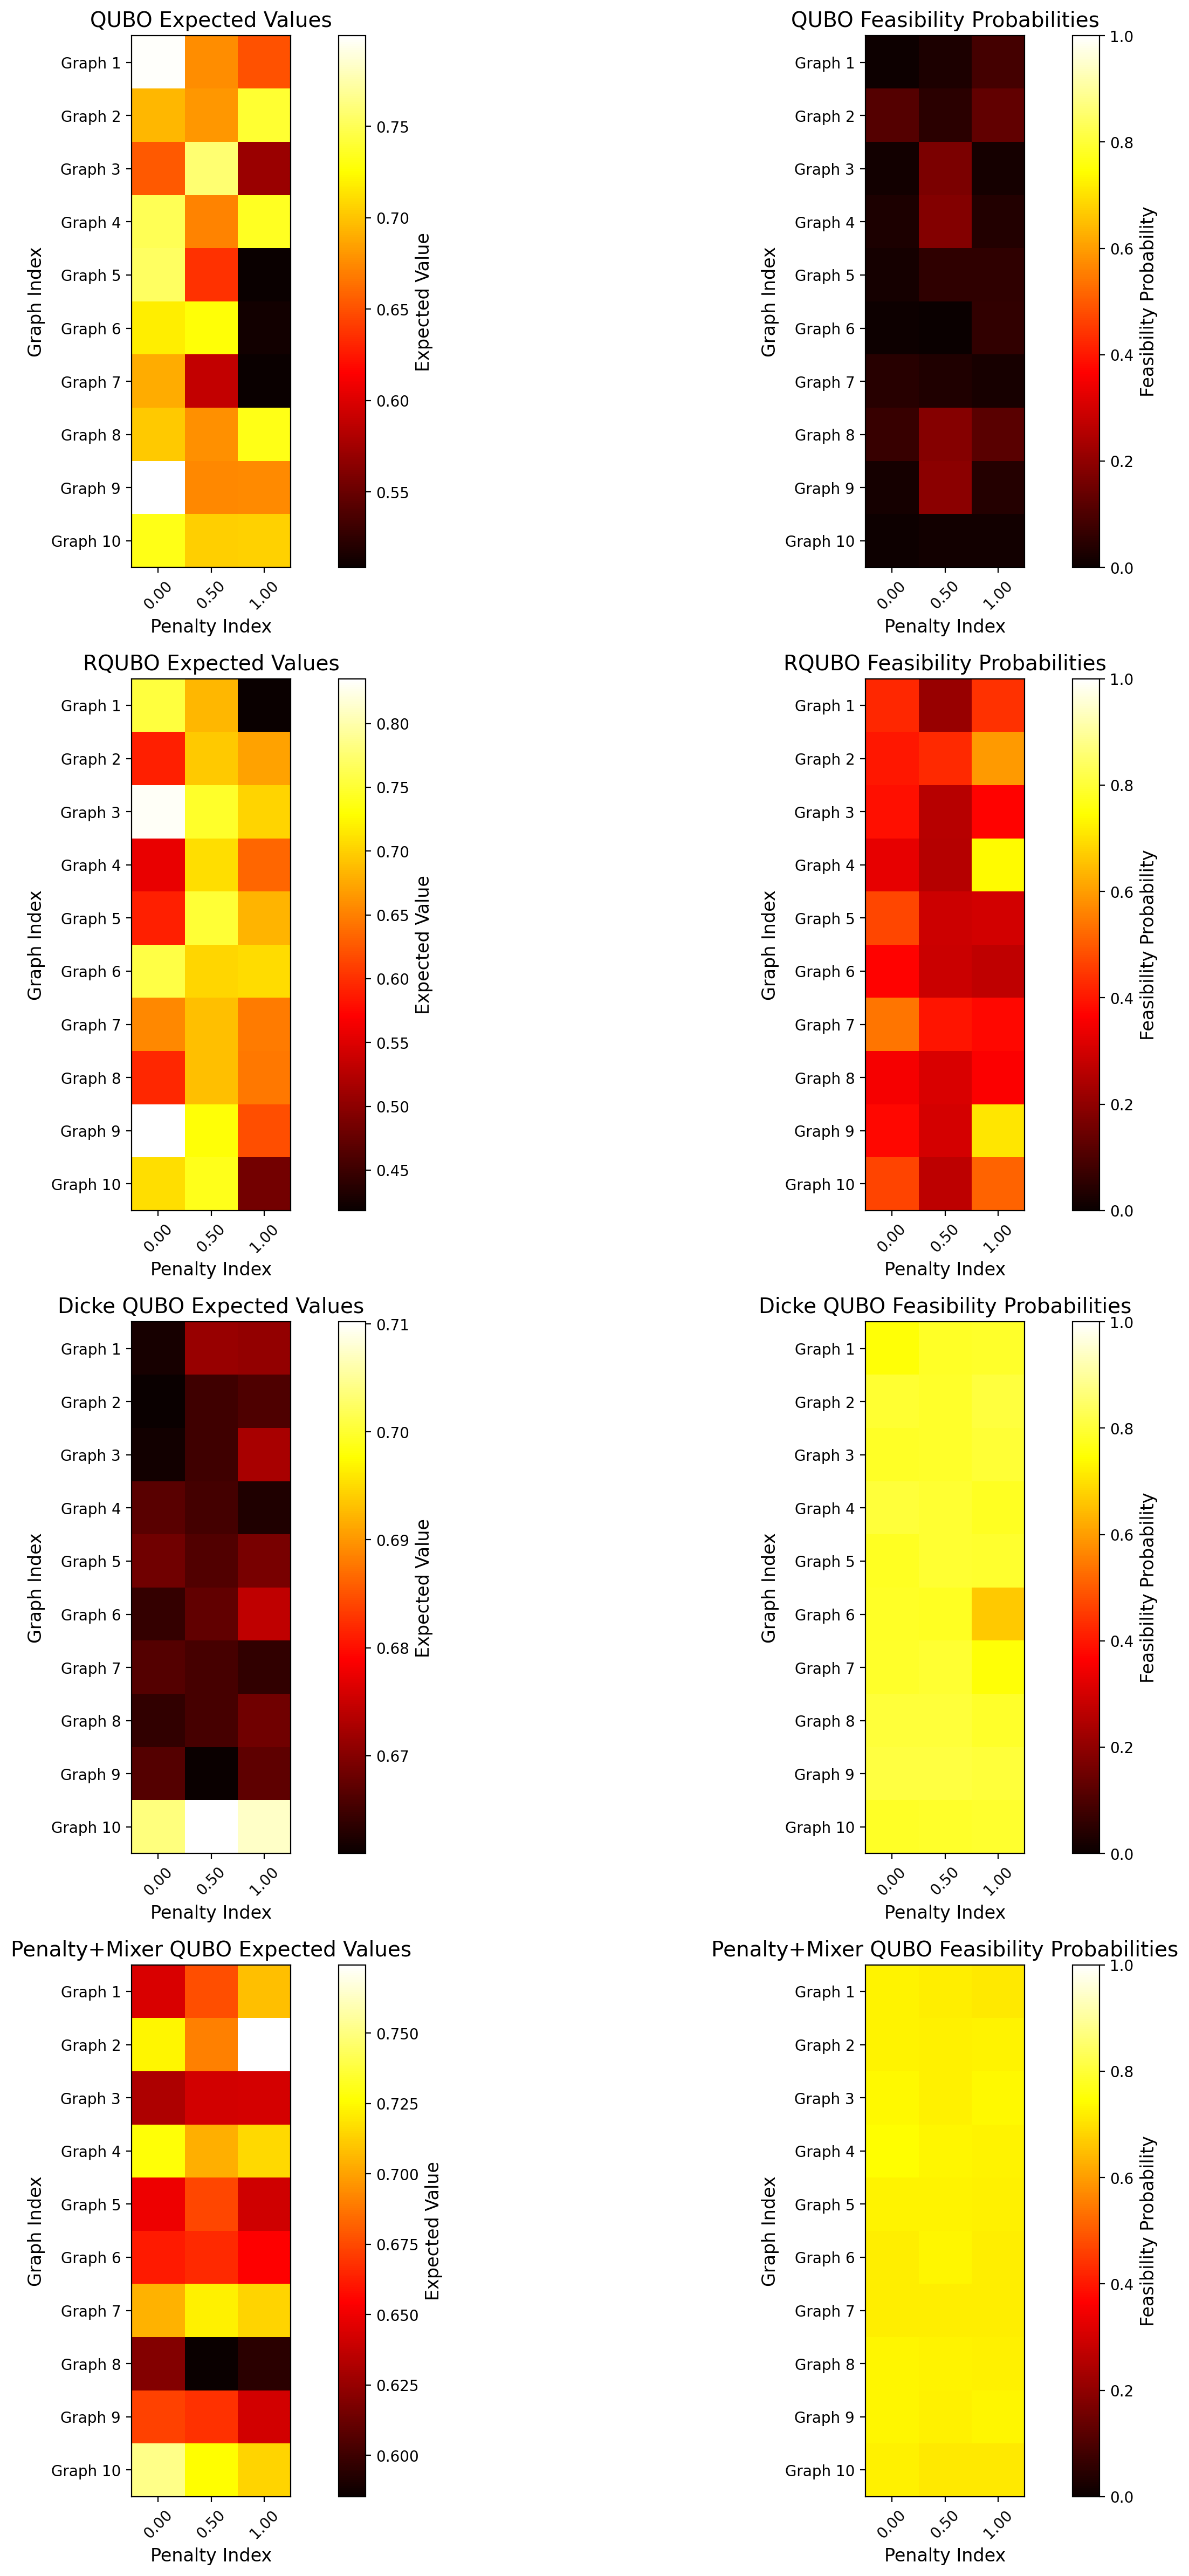

In [3]:
rows = [
    ("QUBO", QUBO_EXP_VALS, QUBO_FEASIBILITY),
    ("RQUBO", RQUBO_EXP_VALS, RQUBO_FEASIBILITY),
    ("Dicke QUBO", DICKE_QUBO_EXP_VALS, DICKE_QUBO_FEASIBILITY),
    ("Penalty+Mixer QUBO", PENALTY_MIXER_QUBO_EXP_VALS, PENALTY_MIXER_QUBO_FEASIBILITY)
]

fig, axs = plt.subplots(len(rows), 2, figsize=(16, 6 * len(rows)), squeeze=False)

for row_idx, (label, exp_vals, feas_vals) in enumerate(rows):
    im0 = axs[row_idx, 0].imshow(exp_vals, cmap='hot', interpolation='nearest')
    cbar0 = fig.colorbar(im0, ax=axs[row_idx, 0])
    cbar0.set_label('Expected Value', fontsize=12)
    axs[row_idx, 0].set_title(f'{label} Expected Values', fontsize=14)
    axs[row_idx, 0].set_xlabel('Penalty Index', fontsize=12)
    axs[row_idx, 0].set_ylabel('Graph Index', fontsize=12)
    axs[row_idx, 0].set_xticks(np.arange(len(penalty_list)))
    axs[row_idx, 0].set_xticklabels([f'{p:.2f}' for p in penalty_list], rotation=45, fontsize=10)
    axs[row_idx, 0].set_yticks(np.arange(num_graphs))
    axs[row_idx, 0].set_yticklabels([f'Graph {i+1}' for i in range(num_graphs)], fontsize=10)

    im1 = axs[row_idx, 1].imshow(feas_vals, cmap='hot', interpolation='nearest', vmin=0, vmax=1)
    cbar1 = fig.colorbar(im1, ax=axs[row_idx, 1])
    cbar1.set_label('Feasibility Probability', fontsize=12)
    axs[row_idx, 1].set_title(f'{label} Feasibility Probabilities', fontsize=14)
    axs[row_idx, 1].set_xlabel('Penalty Index', fontsize=12)
    axs[row_idx, 1].set_ylabel('Graph Index', fontsize=12)
    axs[row_idx, 1].set_xticks(np.arange(len(penalty_list)))
    axs[row_idx, 1].set_xticklabels([f'{p:.2f}' for p in penalty_list], rotation=45, fontsize=10)
    axs[row_idx, 1].set_yticks(np.arange(num_graphs))
    axs[row_idx, 1].set_yticklabels([f'Graph {i+1}' for i in range(num_graphs)], fontsize=10)

plt.tight_layout()
plt.show()

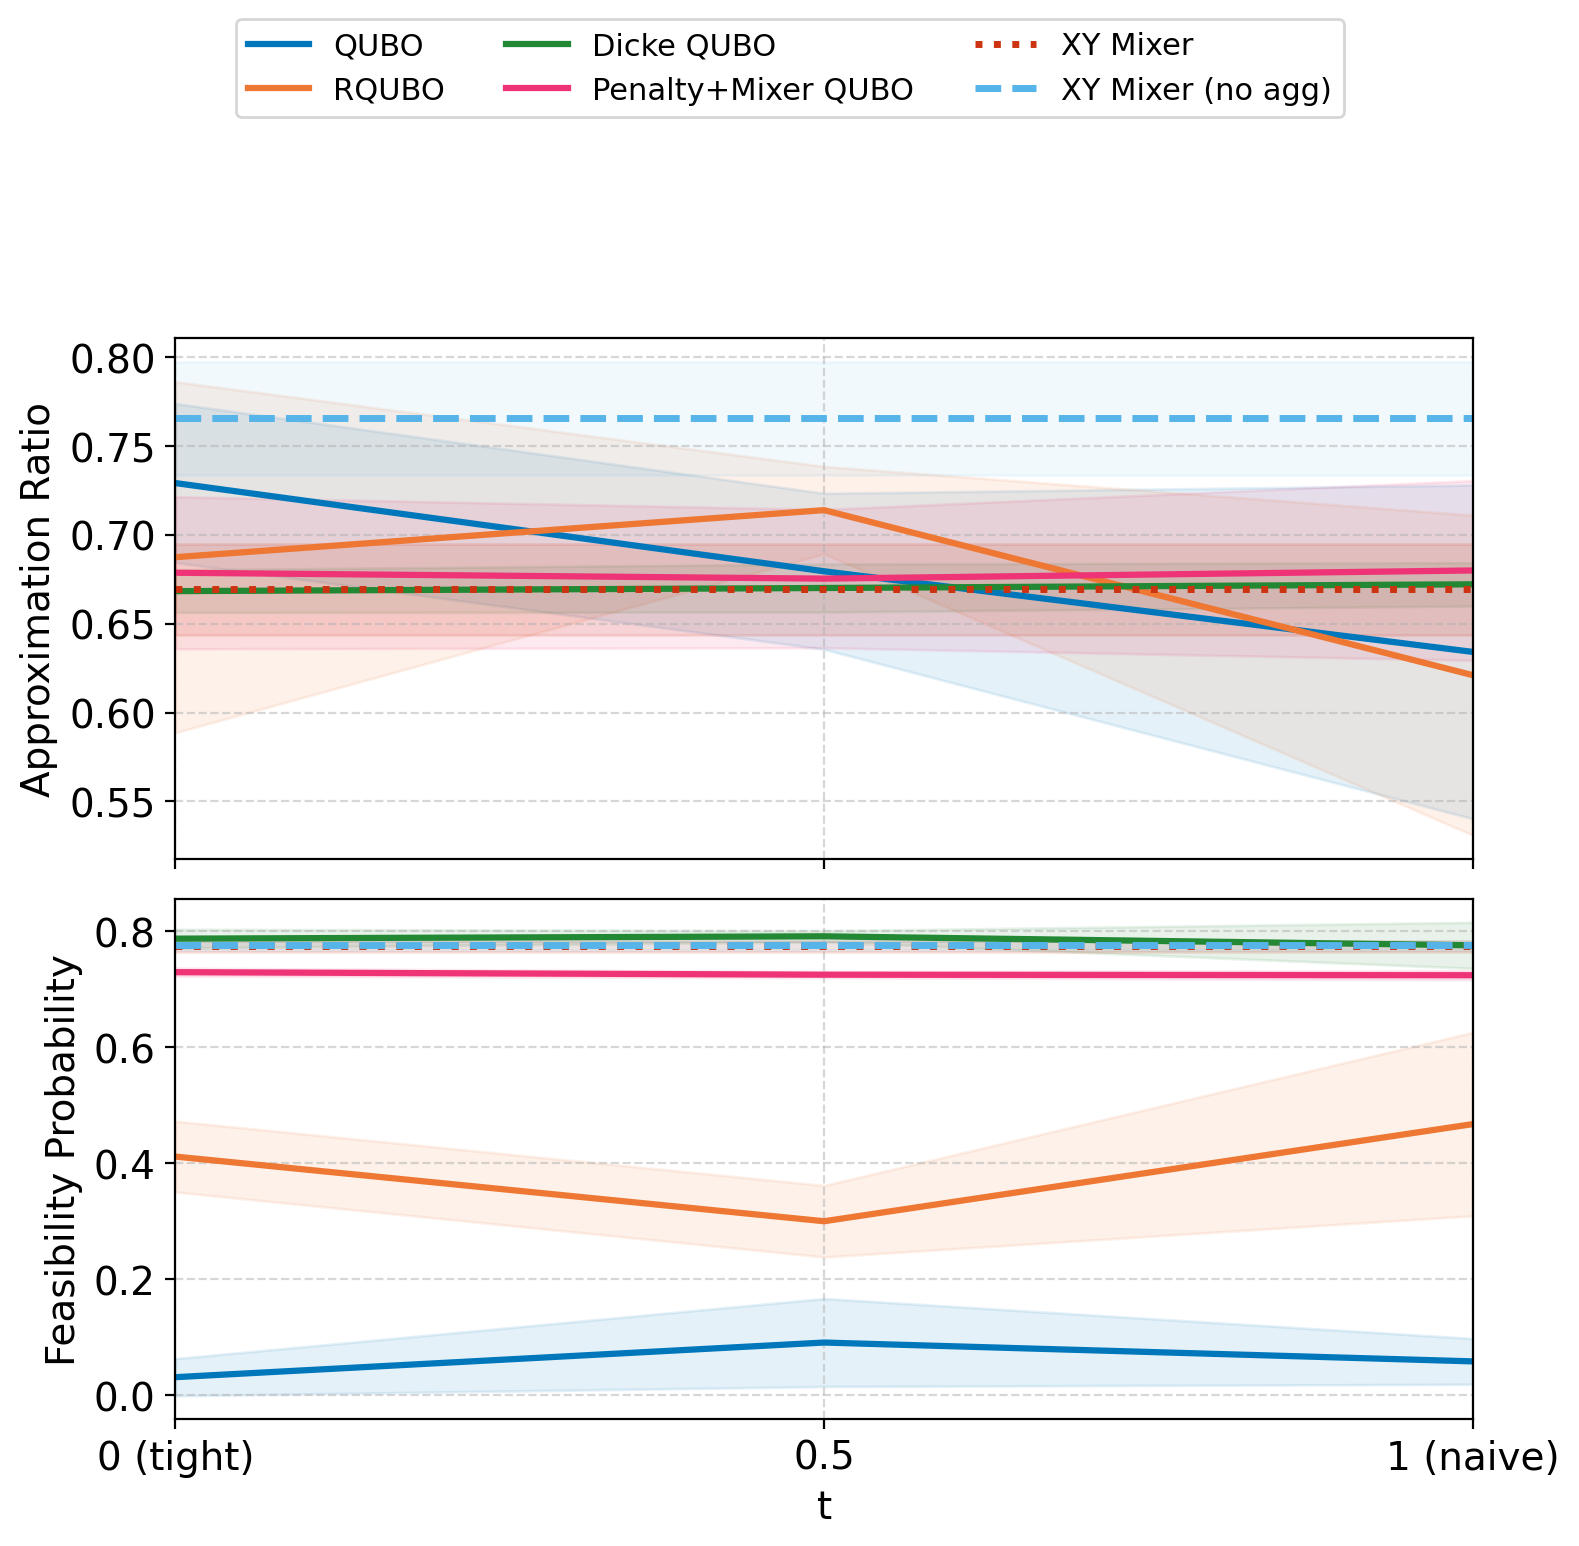

In [4]:
qubo_mean_over_graphs = np.mean(QUBO_EXP_VALS, axis=0)
qubo_std_over_graphs = np.std(QUBO_EXP_VALS, axis=0)
rqubo_mean_over_graphs = np.mean(RQUBO_EXP_VALS, axis=0)
rqubo_std_over_graphs = np.std(RQUBO_EXP_VALS, axis=0)

qubo_mean_feas_prob = np.mean(QUBO_FEASIBILITY, axis=0)
qubo_std_feas_prob = np.std(QUBO_FEASIBILITY, axis=0)
rqubo_mean_feas_prob = np.mean(RQUBO_FEASIBILITY, axis=0)
rqubo_std_feas_prob = np.std(RQUBO_FEASIBILITY, axis=0)

dicke_mean_over_graphs = None
penalty_mixer_mean_over_graphs = None
dicke_mean_feas_prob = None
penalty_mixer_mean_feas_prob = None

if DICKE_QUBO_EXP_VALS is not None:
    dicke_mean_over_graphs = np.mean(DICKE_QUBO_EXP_VALS, axis=0)
    dicke_std_over_graphs = np.std(DICKE_QUBO_EXP_VALS, axis=0)
    dicke_mean_feas_prob = np.mean(DICKE_QUBO_FEASIBILITY, axis=0)
    dicke_std_feas_prob = np.std(DICKE_QUBO_FEASIBILITY, axis=0)

if PENALTY_MIXER_QUBO_EXP_VALS is not None:
    penalty_mixer_mean_over_graphs = np.mean(PENALTY_MIXER_QUBO_EXP_VALS, axis=0)
    penalty_mixer_std_over_graphs = np.std(PENALTY_MIXER_QUBO_EXP_VALS, axis=0)
    penalty_mixer_mean_feas_prob = np.mean(PENALTY_MIXER_QUBO_FEASIBILITY, axis=0)
    penalty_mixer_std_feas_prob = np.std(PENALTY_MIXER_QUBO_FEASIBILITY, axis=0)

xy_mixer_mean = np.mean(XY_MIXER_EXP_VALS) if XY_MIXER_EXP_VALS is not None else None
xy_mixer_std = np.std(XY_MIXER_EXP_VALS) if XY_MIXER_EXP_VALS is not None and np.size(XY_MIXER_EXP_VALS) > 1 else None
xy_mixer_feas_mean = np.mean(XY_MIXER_FEASIBILITY) if XY_MIXER_FEASIBILITY is not None else None
xy_mixer_feas_std = np.std(XY_MIXER_FEASIBILITY) if XY_MIXER_FEASIBILITY is not None and np.size(XY_MIXER_FEASIBILITY) > 1 else None

xy_no_agg_mean = np.mean(XY_MIXER_NO_AGG_EXP_VALS) if XY_MIXER_NO_AGG_EXP_VALS is not None else None
xy_no_agg_std = np.std(XY_MIXER_NO_AGG_EXP_VALS) if XY_MIXER_NO_AGG_EXP_VALS is not None and np.size(XY_MIXER_NO_AGG_EXP_VALS) > 1 else None
xy_no_agg_feas_mean = np.mean(XY_MIXER_NO_AGG_FEASIBILITY) if XY_MIXER_NO_AGG_FEASIBILITY is not None else None
xy_no_agg_feas_std = np.std(XY_MIXER_NO_AGG_FEASIBILITY) if XY_MIXER_NO_AGG_FEASIBILITY is not None and np.size(XY_MIXER_NO_AGG_FEASIBILITY) > 1 else None

# Plotting

# Paul Tol vibrant + sky blue (colorblind-safe, higher chroma)
# Ref: https://personal.sron.nl/~pault/
qubo_color = "#0077BB"
rqubo_color = "#EE7733"
dicke_qubo_color = "#228833"
penalty_mixer_color = "#EE3377"
xy_mixer_color = "#CC3311"
xy_no_agg_color = "#56B4E9"

plt.rcParams["lines.linewidth"] = 2.25
_fill_alpha = 0.10

# Create a 2-row figure: top row for expected ratio, bottom row for feasibility probability.
# By specifying squeeze=False, axs is always a 2D array with shape (2, len(alpha_list))
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# -----------------------------
# Plot in the top row: Expected Approximation Ratio
# -----------------------------
ax_top = axs[0]
ax_top.plot(penalty_list, qubo_mean_over_graphs, label="QUBO", color=qubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(qubo_mean_over_graphs) - np.array(qubo_std_over_graphs),
                    np.array(qubo_mean_over_graphs) + np.array(qubo_std_over_graphs),
                    color=qubo_color, alpha=_fill_alpha)

ax_top.plot(penalty_list, rqubo_mean_over_graphs, label="RQUBO", color=rqubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(rqubo_mean_over_graphs) - np.array(rqubo_std_over_graphs),
                    np.array(rqubo_mean_over_graphs) + np.array(rqubo_std_over_graphs),
                    color=rqubo_color, alpha=_fill_alpha)

if dicke_mean_over_graphs is not None:
    ax_top.plot(penalty_list, dicke_mean_over_graphs, label="Dicke QUBO", color=dicke_qubo_color, linestyle='-')
    ax_top.fill_between(penalty_list,
                        np.array(dicke_mean_over_graphs) - np.array(dicke_std_over_graphs),
                        np.array(dicke_mean_over_graphs) + np.array(dicke_std_over_graphs),
                        color=dicke_qubo_color, alpha=_fill_alpha)

if penalty_mixer_mean_over_graphs is not None:
    ax_top.plot(penalty_list, penalty_mixer_mean_over_graphs, label="Penalty+Mixer QUBO", color=penalty_mixer_color, linestyle='-')
    ax_top.fill_between(penalty_list,
                        np.array(penalty_mixer_mean_over_graphs) - np.array(penalty_mixer_std_over_graphs),
                        np.array(penalty_mixer_mean_over_graphs) + np.array(penalty_mixer_std_over_graphs),
                        color=penalty_mixer_color, alpha=_fill_alpha)

if xy_mixer_mean is not None:
    ax_top.axhline(y=xy_mixer_mean, color=xy_mixer_color, linestyle=':', linewidth=2.5, label="XY Mixer")
    if xy_mixer_std is not None:
        ax_top.axhspan(xy_mixer_mean - xy_mixer_std, xy_mixer_mean + xy_mixer_std,
                       color=xy_mixer_color, alpha=0.12)

if xy_no_agg_mean is not None:
    ax_top.axhline(y=xy_no_agg_mean, color=xy_no_agg_color, linestyle='--', linewidth=2.5, label="XY Mixer (no agg)")
    if xy_no_agg_std is not None:
        ax_top.axhspan(xy_no_agg_mean - xy_no_agg_std, xy_no_agg_mean + xy_no_agg_std,
                       color=xy_no_agg_color, alpha=0.08)

ax_top.grid(True, which='both', linestyle='--', alpha=0.5)
#ax_top.set_ylim(0, 1)
ax_top.set_ylabel('Approximation Ratio', fontsize=14)
plt.grid

# -----------------------------
# Plot in the bottom row: Feasibility Probability
# -----------------------------
ax_bottom = axs[1]
ax_bottom.plot(penalty_list, qubo_mean_feas_prob, label="QUBO", color=qubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(qubo_mean_feas_prob) - np.array(qubo_std_feas_prob),
                    np.array(qubo_mean_feas_prob) + np.array(qubo_std_feas_prob),
                    color=qubo_color, alpha=_fill_alpha)

ax_bottom.plot(penalty_list, rqubo_mean_feas_prob, label="RQUBO", color=rqubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(rqubo_mean_feas_prob) - np.array(rqubo_std_feas_prob),
                    np.array(rqubo_mean_feas_prob) + np.array(rqubo_std_feas_prob),
                    color=rqubo_color, alpha=_fill_alpha)

if dicke_mean_feas_prob is not None:
    ax_bottom.plot(penalty_list, dicke_mean_feas_prob, label="Dicke QUBO", color=dicke_qubo_color, linestyle='-')
    ax_bottom.fill_between(penalty_list,
                        np.array(dicke_mean_feas_prob) - np.array(dicke_std_feas_prob),
                        np.array(dicke_mean_feas_prob) + np.array(dicke_std_feas_prob),
                        color=dicke_qubo_color, alpha=_fill_alpha)

if penalty_mixer_mean_feas_prob is not None:
    ax_bottom.plot(penalty_list, penalty_mixer_mean_feas_prob, label="Penalty+Mixer QUBO", color=penalty_mixer_color, linestyle='-')
    ax_bottom.fill_between(penalty_list,
                        np.array(penalty_mixer_mean_feas_prob) - np.array(penalty_mixer_std_feas_prob),
                        np.array(penalty_mixer_mean_feas_prob) + np.array(penalty_mixer_std_feas_prob),
                        color=penalty_mixer_color, alpha=_fill_alpha)

if xy_mixer_feas_mean is not None:
    ax_bottom.axhline(y=xy_mixer_feas_mean, color=xy_mixer_color, linestyle=':', linewidth=2.5, label="XY Mixer")
    if xy_mixer_feas_std is not None:
        ax_bottom.axhspan(xy_mixer_feas_mean - xy_mixer_feas_std, xy_mixer_feas_mean + xy_mixer_feas_std,
                          color=xy_mixer_color, alpha=0.12)

if xy_no_agg_feas_mean is not None:
    ax_bottom.axhline(y=xy_no_agg_feas_mean, color=xy_no_agg_color, linestyle='--', linewidth=2.5, label="XY Mixer (no agg)")
    if xy_no_agg_feas_std is not None:
        ax_bottom.axhspan(xy_no_agg_feas_mean - xy_no_agg_feas_std, xy_no_agg_feas_mean + xy_no_agg_feas_std,
                          color=xy_no_agg_color, alpha=0.08)

ax_bottom.grid(True, which='both', linestyle='--', alpha=0.5)
#ax_bottom.set_ylim(0, .5)
ax_bottom.set_xlabel('t', fontsize=14)
ax_bottom.set_xticks([0, 0.5, 1])
ax_bottom.set_xticklabels(["0 (tight)", "0.5", "1 (naive)"], fontsize=12)
ax_bottom.set_ylabel('Feasibility Probability', fontsize=14)

handles, labels = ax_top.get_legend_handles_labels()
_leg = fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
    bbox_transform=fig.transFigure,
    ncol=3,
    fontsize=11,
    frameon=True,
)
_leg.set_clip_on(False)

for ax in axs:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    plt.xlim(0, 1)

plt.tight_layout(rect=[0, 0, 1, 0.78])


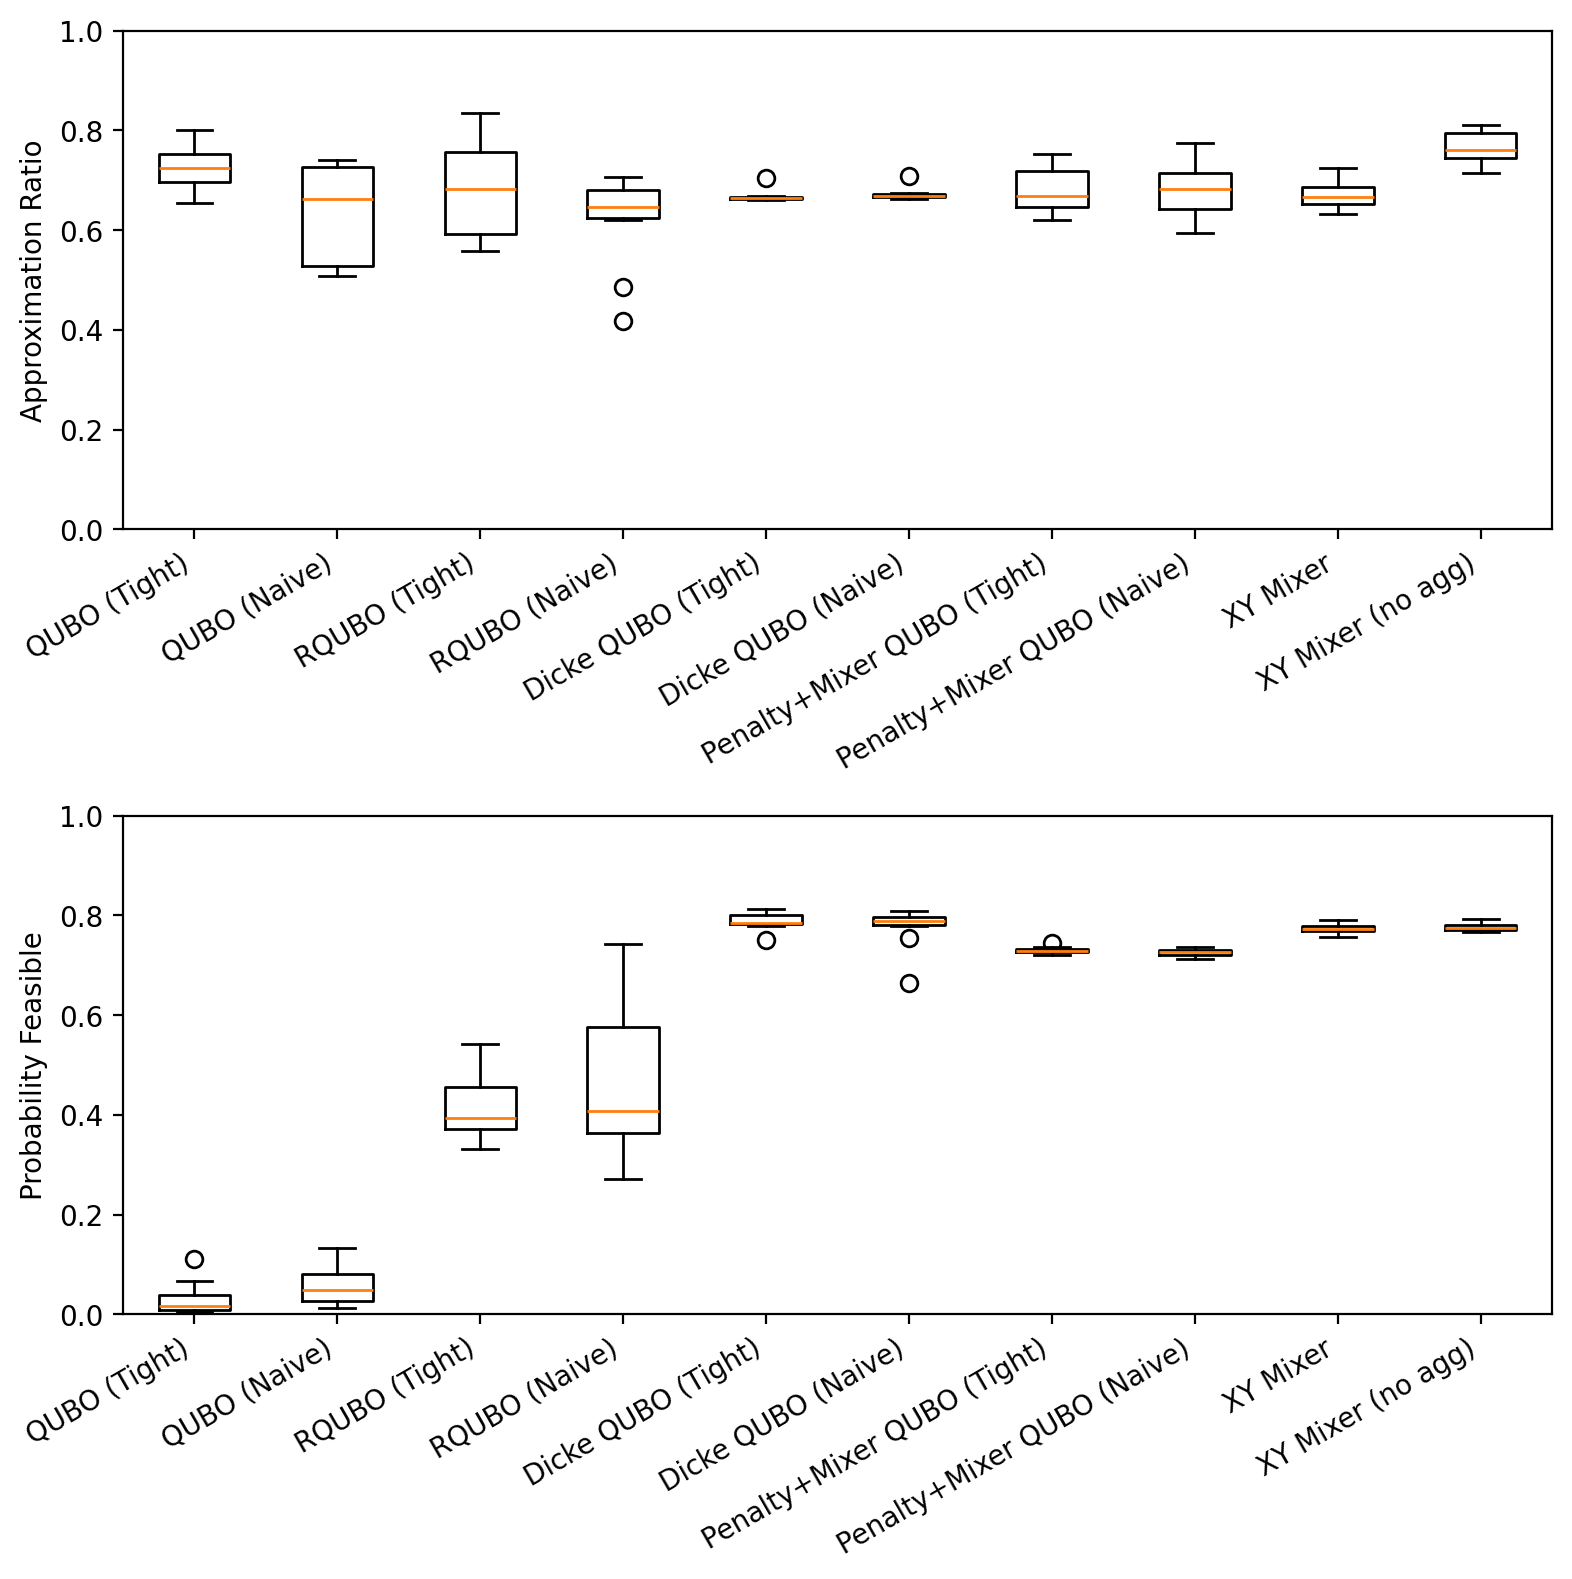

In [5]:
# Box Plot

model_specs = [
    ("QUBO (Tight)", QUBO_EXP_VALS[:, 0], QUBO_FEASIBILITY[:, 0]),
    ("QUBO (Naive)", QUBO_EXP_VALS[:, -1], QUBO_FEASIBILITY[:, -1]),
    ("RQUBO (Tight)", RQUBO_EXP_VALS[:, 0], RQUBO_FEASIBILITY[:, 0]),
    ("RQUBO (Naive)", RQUBO_EXP_VALS[:, -1], RQUBO_FEASIBILITY[:, -1]),
]

if DICKE_QUBO_EXP_VALS is not None:
    model_specs.append(("Dicke QUBO (Tight)", DICKE_QUBO_EXP_VALS[:, 0], DICKE_QUBO_FEASIBILITY[:, 0]))
    model_specs.append(("Dicke QUBO (Naive)", DICKE_QUBO_EXP_VALS[:, -1], DICKE_QUBO_FEASIBILITY[:, -1]))

if PENALTY_MIXER_QUBO_EXP_VALS is not None:
    model_specs.append(("Penalty+Mixer QUBO (Tight)", PENALTY_MIXER_QUBO_EXP_VALS[:, 0], PENALTY_MIXER_QUBO_FEASIBILITY[:, 0]))
    model_specs.append(("Penalty+Mixer QUBO (Naive)", PENALTY_MIXER_QUBO_EXP_VALS[:, -1], PENALTY_MIXER_QUBO_FEASIBILITY[:, -1]))

if XY_MIXER_EXP_VALS is not None:
    model_specs.append(("XY Mixer", XY_MIXER_EXP_VALS, XY_MIXER_FEASIBILITY))

if XY_MIXER_NO_AGG_EXP_VALS is not None:
    model_specs.append(("XY Mixer (no agg)", XY_MIXER_NO_AGG_EXP_VALS, XY_MIXER_NO_AGG_FEASIBILITY))

model_labels = [label for label, _, _ in model_specs]
model_means = {label: values for label, values, _ in model_specs}
model_feasibility_probs = {label: feas for label, _, feas in model_specs}

fig, axs = plt.subplots(2, 1, figsize=(8, 8))

# First subplot: Approximation Ratio
data_for_boxplot = [model_means[label] for label in model_labels]
axs[0].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[0].set_ylabel("Approximation Ratio")
axs[0].set_xticklabels(model_labels, rotation=30, ha='right')
axs[0].set_ylim(0, 1)

# Second subplot: Probability Feasible
data_for_boxplot = [model_feasibility_probs[label] for label in model_labels]
axs[1].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[1].set_ylabel("Probability Feasible")
axs[1].set_xticklabels(model_labels, rotation=30, ha='right')
axs[1].set_ylim(0, 1)

plt.tight_layout()

## Filter out expected values of zero resulting from all shots being discarded due to infeasibility. This occurs especially with QUBO model which consistently has a low feasibility probability.

In [6]:
# For each column in data matrix, drop zero values and average the rest
def average_non_zero(data):
    return np.array([np.mean(col[col != 0]) for col in data.T])

def std_non_zero(data):
    return np.array([np.std(col[col != 0]) for col in data.T])

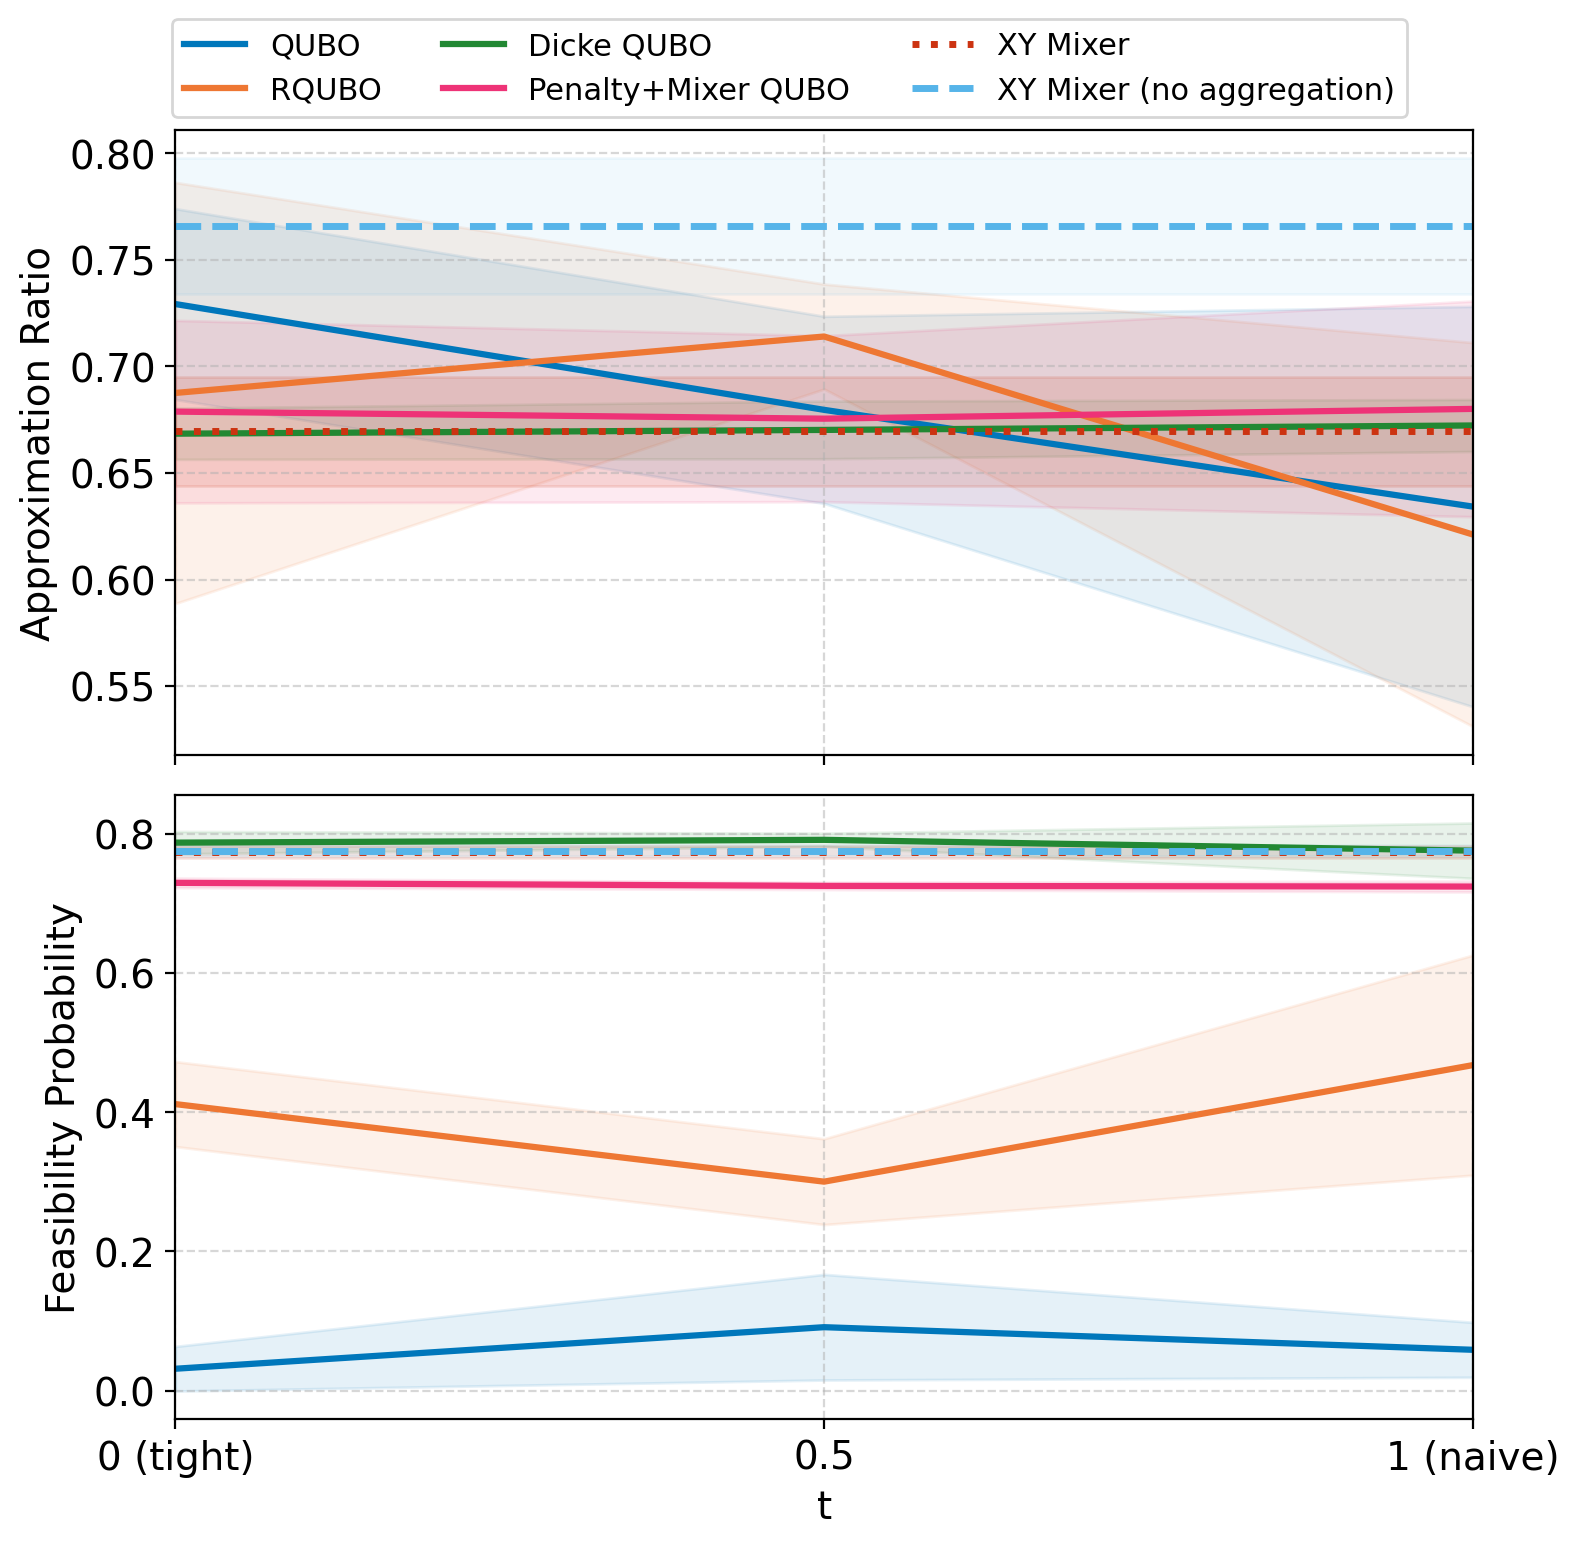

In [7]:
qubo_mean_over_graphs = average_non_zero(QUBO_EXP_VALS)
qubo_std_over_graphs = std_non_zero(QUBO_EXP_VALS)
rqubo_mean_over_graphs = average_non_zero(RQUBO_EXP_VALS)
rqubo_std_over_graphs = std_non_zero(RQUBO_EXP_VALS)

qubo_mean_feas_prob = np.mean(QUBO_FEASIBILITY, axis=0)
qubo_std_feas_prob = np.std(QUBO_FEASIBILITY, axis=0)
rqubo_mean_feas_prob = np.mean(RQUBO_FEASIBILITY, axis=0)
rqubo_std_feas_prob = np.std(RQUBO_FEASIBILITY, axis=0)

dicke_mean_over_graphs = None
penalty_mixer_mean_over_graphs = None
dicke_mean_feas_prob = None
penalty_mixer_mean_feas_prob = None

if DICKE_QUBO_EXP_VALS is not None:
    dicke_mean_over_graphs = average_non_zero(DICKE_QUBO_EXP_VALS)
    dicke_std_over_graphs = std_non_zero(DICKE_QUBO_EXP_VALS)
    dicke_mean_feas_prob = np.mean(DICKE_QUBO_FEASIBILITY, axis=0)
    dicke_std_feas_prob = np.std(DICKE_QUBO_FEASIBILITY, axis=0)

if PENALTY_MIXER_QUBO_EXP_VALS is not None:
    penalty_mixer_mean_over_graphs = average_non_zero(PENALTY_MIXER_QUBO_EXP_VALS)
    penalty_mixer_std_over_graphs = std_non_zero(PENALTY_MIXER_QUBO_EXP_VALS)
    penalty_mixer_mean_feas_prob = np.mean(PENALTY_MIXER_QUBO_FEASIBILITY, axis=0)
    penalty_mixer_std_feas_prob = np.std(PENALTY_MIXER_QUBO_FEASIBILITY, axis=0)

xy_mixer_mean = np.mean(XY_MIXER_EXP_VALS) if XY_MIXER_EXP_VALS is not None else None
xy_mixer_std = np.std(XY_MIXER_EXP_VALS) if XY_MIXER_EXP_VALS is not None and np.size(XY_MIXER_EXP_VALS) > 1 else None
xy_mixer_feas_mean = np.mean(XY_MIXER_FEASIBILITY) if XY_MIXER_FEASIBILITY is not None else None
xy_mixer_feas_std = np.std(XY_MIXER_FEASIBILITY) if XY_MIXER_FEASIBILITY is not None and np.size(XY_MIXER_FEASIBILITY) > 1 else None

xy_no_agg_mean = np.mean(XY_MIXER_NO_AGG_EXP_VALS) if XY_MIXER_NO_AGG_EXP_VALS is not None else None
xy_no_agg_std = np.std(XY_MIXER_NO_AGG_EXP_VALS) if XY_MIXER_NO_AGG_EXP_VALS is not None and np.size(XY_MIXER_NO_AGG_EXP_VALS) > 1 else None
xy_no_agg_feas_mean = np.mean(XY_MIXER_NO_AGG_FEASIBILITY) if XY_MIXER_NO_AGG_FEASIBILITY is not None else None
xy_no_agg_feas_std = np.std(XY_MIXER_NO_AGG_FEASIBILITY) if XY_MIXER_NO_AGG_FEASIBILITY is not None and np.size(XY_MIXER_NO_AGG_FEASIBILITY) > 1 else None

# Plotting

# Paul Tol vibrant + sky blue (colorblind-safe, higher chroma)
# Ref: https://personal.sron.nl/~pault/
qubo_color = "#0077BB"
rqubo_color = "#EE7733"
dicke_qubo_color = "#228833"
penalty_mixer_color = "#EE3377"
xy_mixer_color = "#CC3311"
xy_no_agg_color = "#56B4E9"

plt.rcParams["lines.linewidth"] = 2.25
_fill_alpha = 0.10

# Create a 2-row figure: top row for expected ratio, bottom row for feasibility probability.
# By specifying squeeze=False, axs is always a 2D array with shape (2, len(alpha_list))
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# -----------------------------
# Plot in the top row: Expected Approximation Ratio
# -----------------------------
ax_top = axs[0]
ax_top.plot(penalty_list, qubo_mean_over_graphs, label="QUBO", color=qubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(qubo_mean_over_graphs) - np.array(qubo_std_over_graphs),
                    np.array(qubo_mean_over_graphs) + np.array(qubo_std_over_graphs),
                    color=qubo_color, alpha=_fill_alpha)

ax_top.plot(penalty_list, rqubo_mean_over_graphs, label="RQUBO", color=rqubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(rqubo_mean_over_graphs) - np.array(rqubo_std_over_graphs),
                    np.array(rqubo_mean_over_graphs) + np.array(rqubo_std_over_graphs),
                    color=rqubo_color, alpha=_fill_alpha)

if dicke_mean_over_graphs is not None:
    ax_top.plot(penalty_list, dicke_mean_over_graphs, label="Dicke QUBO", color=dicke_qubo_color, linestyle='-')
    ax_top.fill_between(penalty_list,
                        np.array(dicke_mean_over_graphs) - np.array(dicke_std_over_graphs),
                        np.array(dicke_mean_over_graphs) + np.array(dicke_std_over_graphs),
                        color=dicke_qubo_color, alpha=_fill_alpha)

if penalty_mixer_mean_over_graphs is not None:
    ax_top.plot(penalty_list, penalty_mixer_mean_over_graphs, label="Penalty+Mixer QUBO", color=penalty_mixer_color, linestyle='-')
    ax_top.fill_between(penalty_list,
                        np.array(penalty_mixer_mean_over_graphs) - np.array(penalty_mixer_std_over_graphs),
                        np.array(penalty_mixer_mean_over_graphs) + np.array(penalty_mixer_std_over_graphs),
                        color=penalty_mixer_color, alpha=_fill_alpha)

if xy_mixer_mean is not None:
    ax_top.axhline(y=xy_mixer_mean, color=xy_mixer_color, linestyle=':', linewidth=2.5, label="XY Mixer")
    if xy_mixer_std is not None:
        ax_top.axhspan(xy_mixer_mean - xy_mixer_std, xy_mixer_mean + xy_mixer_std,
                       color=xy_mixer_color, alpha=0.12)

if xy_no_agg_mean is not None:
    ax_top.axhline(y=xy_no_agg_mean, color=xy_no_agg_color, linestyle='--', linewidth=2.5, label="XY Mixer (no aggregation)")
    if xy_no_agg_std is not None:
        ax_top.axhspan(xy_no_agg_mean - xy_no_agg_std, xy_no_agg_mean + xy_no_agg_std,
                       color=xy_no_agg_color, alpha=0.08)

ax_top.grid(True, which='both', linestyle='--', alpha=0.5)
# ax_top.set_ylim(.5, 1)
ax_top.set_ylabel('Approximation Ratio', fontsize=14)
plt.grid

# -----------------------------
# Plot in the bottom row: Feasibility Probability
# -----------------------------
ax_bottom = axs[1]
ax_bottom.plot(penalty_list, qubo_mean_feas_prob, label="QUBO", color=qubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(qubo_mean_feas_prob) - np.array(qubo_std_feas_prob),
                    np.array(qubo_mean_feas_prob) + np.array(qubo_std_feas_prob),
                    color=qubo_color, alpha=_fill_alpha)

ax_bottom.plot(penalty_list, rqubo_mean_feas_prob, label="RQUBO", color=rqubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(rqubo_mean_feas_prob) - np.array(rqubo_std_feas_prob),
                    np.array(rqubo_mean_feas_prob) + np.array(rqubo_std_feas_prob),
                    color=rqubo_color, alpha=_fill_alpha)

if dicke_mean_feas_prob is not None:
    ax_bottom.plot(penalty_list, dicke_mean_feas_prob, label="Dicke QUBO", color=dicke_qubo_color, linestyle='-')
    ax_bottom.fill_between(penalty_list,
                        np.array(dicke_mean_feas_prob) - np.array(dicke_std_feas_prob),
                        np.array(dicke_mean_feas_prob) + np.array(dicke_std_feas_prob),
                        color=dicke_qubo_color, alpha=_fill_alpha)

if penalty_mixer_mean_feas_prob is not None:
    ax_bottom.plot(penalty_list, penalty_mixer_mean_feas_prob, label="Penalty+Mixer QUBO", color=penalty_mixer_color, linestyle='-')
    ax_bottom.fill_between(penalty_list,
                        np.array(penalty_mixer_mean_feas_prob) - np.array(penalty_mixer_std_feas_prob),
                        np.array(penalty_mixer_mean_feas_prob) + np.array(penalty_mixer_std_feas_prob),
                        color=penalty_mixer_color, alpha=_fill_alpha)

if xy_mixer_feas_mean is not None:
    ax_bottom.axhline(y=xy_mixer_feas_mean, color=xy_mixer_color, linestyle=':', linewidth=2.5, label="XY Mixer")
    if xy_mixer_feas_std is not None:
        ax_bottom.axhspan(xy_mixer_feas_mean - xy_mixer_feas_std, xy_mixer_feas_mean + xy_mixer_feas_std,
                          color=xy_mixer_color, alpha=0.12)

if xy_no_agg_feas_mean is not None:
    ax_bottom.axhline(y=xy_no_agg_feas_mean, color=xy_no_agg_color, linestyle='--', linewidth=2.5, label="XY Mixer (no aggregation)")
    if xy_no_agg_feas_std is not None:
        ax_bottom.axhspan(xy_no_agg_feas_mean - xy_no_agg_feas_std, xy_no_agg_feas_mean + xy_no_agg_feas_std,
                          color=xy_no_agg_color, alpha=0.08)

ax_bottom.grid(True, which='both', linestyle='--', alpha=0.5)
# ax_bottom.set_ylim(0, 1.05)
ax_bottom.set_xlabel('t', fontsize=14)
ax_bottom.set_xticks([0, 0.5, 1])
ax_bottom.set_xticklabels(["0 (tight)", "0.5", "1 (naive)"], fontsize=12)
ax_bottom.set_ylabel('Feasibility Probability', fontsize=14)

handles, labels = ax_top.get_legend_handles_labels()
_leg = fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
    bbox_transform=fig.transFigure,
    ncol=3,
    fontsize=11,
    frameon=True,
)
_leg.set_clip_on(False)

for ax in axs:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    plt.xlim(0, 1)

plt.tight_layout(rect=[0, 0, 1, 0.91])

data_tag = os.path.splitext(os.path.basename(loaded_data_path))[0]
fig.savefig(
    os.path.join("Data", f"interpolated_penalties_{data_tag}_augmented.pdf"),
    bbox_inches="tight",
    pad_inches=0.2,
    bbox_extra_artists=[_leg],
)

In [8]:
print("feasibility probability ratio:",penalty_mixer_mean_feas_prob)
print("average ratio:", np.mean(rqubo_mean_feas_prob / qubo_mean_feas_prob))

feasibility probability ratio: [0.72969 0.72538 0.72442]
average ratio: 8.109900462602967


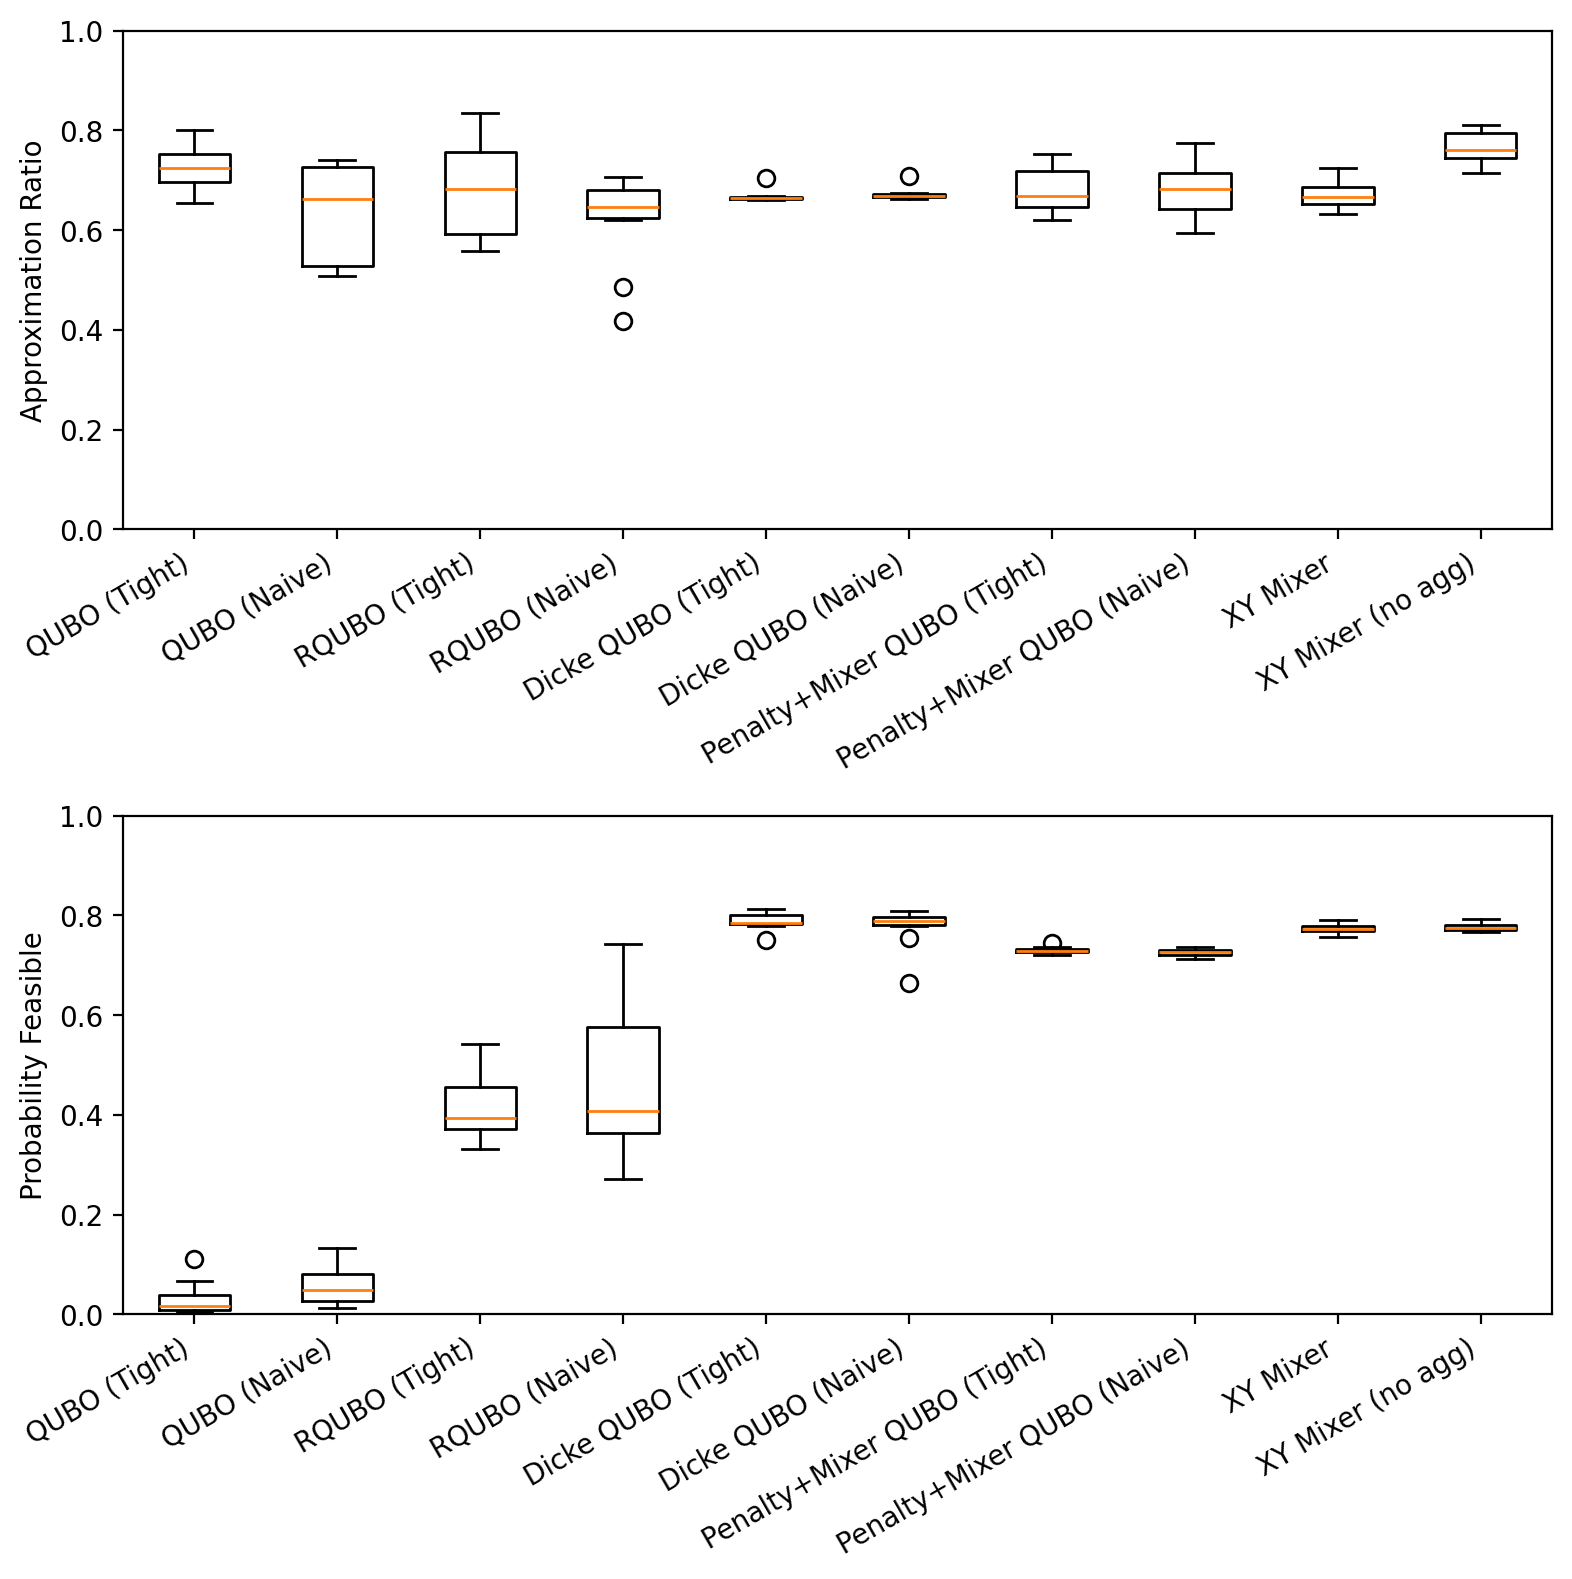

In [9]:
# Box Plot

def drop_zeros(values):
    return values[values != 0]

model_specs = [
    ("QUBO (Tight)", drop_zeros(QUBO_EXP_VALS[:, 0]), QUBO_FEASIBILITY[:, 0]),
    ("QUBO (Naive)", drop_zeros(QUBO_EXP_VALS[:, -1]), QUBO_FEASIBILITY[:, -1]),
    ("RQUBO (Tight)", drop_zeros(RQUBO_EXP_VALS[:, 0]), RQUBO_FEASIBILITY[:, 0]),
    ("RQUBO (Naive)", drop_zeros(RQUBO_EXP_VALS[:, -1]), RQUBO_FEASIBILITY[:, -1]),
]

if DICKE_QUBO_EXP_VALS is not None:
    model_specs.append(("Dicke QUBO (Tight)", drop_zeros(DICKE_QUBO_EXP_VALS[:, 0]), DICKE_QUBO_FEASIBILITY[:, 0]))
    model_specs.append(("Dicke QUBO (Naive)", drop_zeros(DICKE_QUBO_EXP_VALS[:, -1]), DICKE_QUBO_FEASIBILITY[:, -1]))

if PENALTY_MIXER_QUBO_EXP_VALS is not None:
    model_specs.append(("Penalty+Mixer QUBO (Tight)", drop_zeros(PENALTY_MIXER_QUBO_EXP_VALS[:, 0]), PENALTY_MIXER_QUBO_FEASIBILITY[:, 0]))
    model_specs.append(("Penalty+Mixer QUBO (Naive)", drop_zeros(PENALTY_MIXER_QUBO_EXP_VALS[:, -1]), PENALTY_MIXER_QUBO_FEASIBILITY[:, -1]))

if XY_MIXER_EXP_VALS is not None:
    model_specs.append(("XY Mixer", drop_zeros(XY_MIXER_EXP_VALS), XY_MIXER_FEASIBILITY))

if XY_MIXER_NO_AGG_EXP_VALS is not None:
    model_specs.append(("XY Mixer (no agg)", drop_zeros(XY_MIXER_NO_AGG_EXP_VALS), XY_MIXER_NO_AGG_FEASIBILITY))

model_labels = [label for label, _, _ in model_specs]
model_means = {label: values for label, values, _ in model_specs}
model_feasibility_probs = {label: feas for label, _, feas in model_specs}

fig, axs = plt.subplots(2, 1, figsize=(8, 8))

# First subplot: Approximation Ratio
data_for_boxplot = [model_means[label] for label in model_labels]
axs[0].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[0].set_ylabel("Approximation Ratio")
axs[0].set_xticklabels(model_labels, rotation=30, ha='right')
axs[0].set_ylim(0, 1)

# Second subplot: Probability Feasible
data_for_boxplot = [model_feasibility_probs[label] for label in model_labels]
axs[1].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[1].set_ylabel("Probability Feasible")
axs[1].set_xticklabels(model_labels, rotation=30, ha='right')
axs[1].set_ylim(0, 1)

plt.tight_layout()

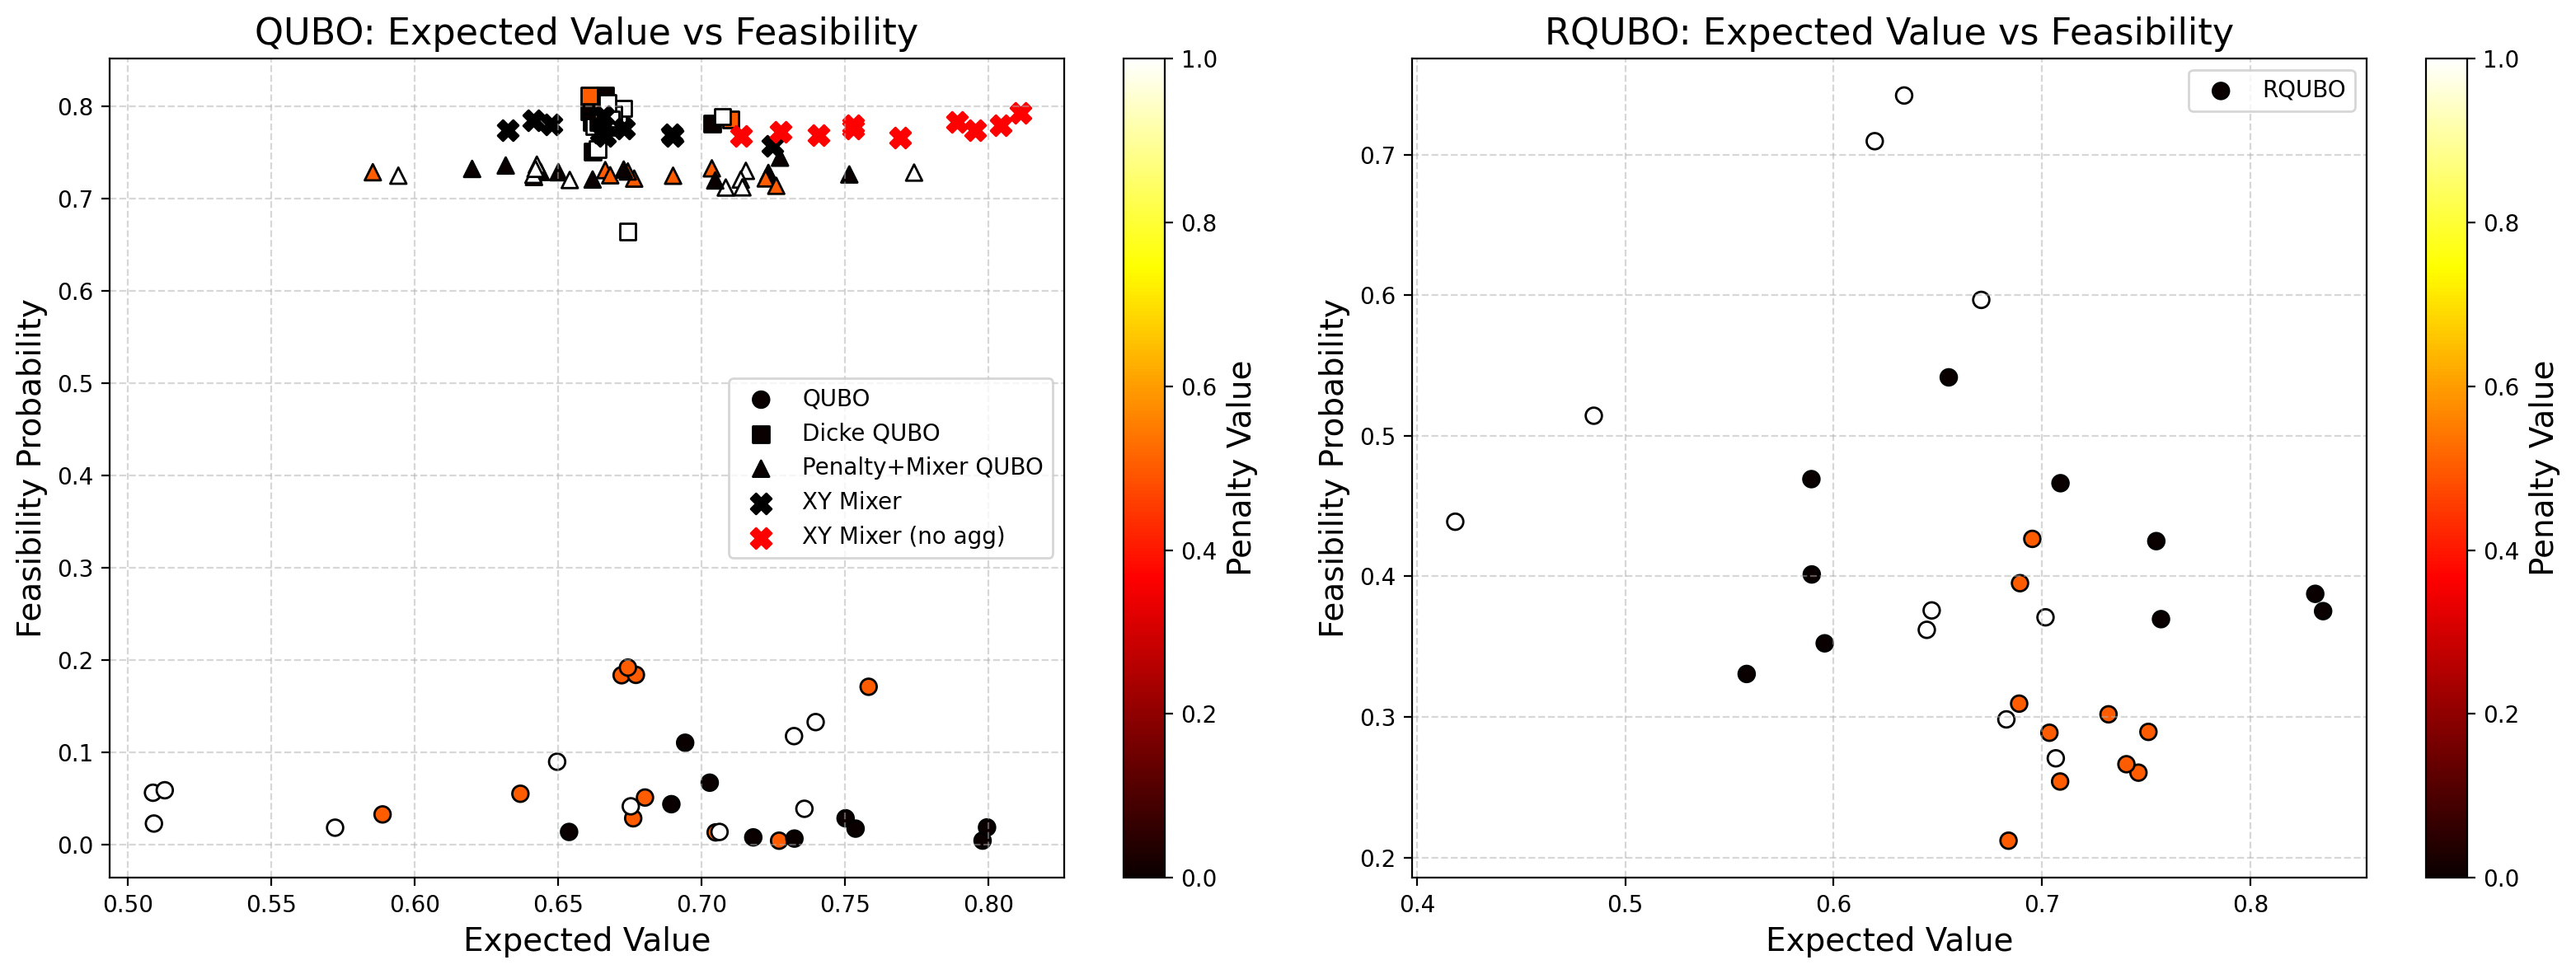

In [10]:
# Scatter of ALL data points

# Create color arrays for scatter plots.
# For each row (graph) we assign the penalty_list values.
colors = np.tile(penalty_list, (QUBO_EXP_VALS.shape[0], 1))  # shape (num_graphs, num_penalties)

# Flatten the matrices for plotting
qubo_exp_flat = QUBO_EXP_VALS.flatten()
qubo_feas_flat = QUBO_FEASIBILITY.flatten()
rqubo_exp_flat = RQUBO_EXP_VALS.flatten()
rqubo_feas_flat = RQUBO_FEASIBILITY.flatten()
colors_flat = colors.flatten()

dicke_exp_flat = DICKE_QUBO_EXP_VALS.flatten() if DICKE_QUBO_EXP_VALS is not None else None
dicke_feas_flat = DICKE_QUBO_FEASIBILITY.flatten() if DICKE_QUBO_FEASIBILITY is not None else None
pm_exp_flat = PENALTY_MIXER_QUBO_EXP_VALS.flatten() if PENALTY_MIXER_QUBO_EXP_VALS is not None else None
pm_feas_flat = PENALTY_MIXER_QUBO_FEASIBILITY.flatten() if PENALTY_MIXER_QUBO_FEASIBILITY is not None else None

# Create figure with two subplots.
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot for QUBO results
sc0 = axs[0].scatter(qubo_exp_flat, qubo_feas_flat, c=colors_flat, cmap='hot', s=50, edgecolor='k', label="QUBO")

if dicke_exp_flat is not None:
    axs[0].scatter(dicke_exp_flat, dicke_feas_flat, c=colors_flat, cmap='hot', s=50, edgecolor='k', marker='s', label="Dicke QUBO")
if pm_exp_flat is not None:
    axs[0].scatter(pm_exp_flat, pm_feas_flat, c=colors_flat, cmap='hot', s=50, edgecolor='k', marker='^', label="Penalty+Mixer QUBO")
if XY_MIXER_EXP_VALS is not None:
    axs[0].scatter(XY_MIXER_EXP_VALS, XY_MIXER_FEASIBILITY, color='black', s=80, marker='X', label="XY Mixer")
if XY_MIXER_NO_AGG_EXP_VALS is not None:
    axs[0].scatter(XY_MIXER_NO_AGG_EXP_VALS, XY_MIXER_NO_AGG_FEASIBILITY, color='red', s=80, marker='X', label="XY Mixer (no agg)")

axs[0].set_xlabel('Expected Value', fontsize=14)
axs[0].set_ylabel('Feasibility Probability', fontsize=14)
axs[0].set_title('QUBO: Expected Value vs Feasibility', fontsize=16)
axs[0].grid(True, which='both', linestyle='--', alpha=0.5)
axs[0].legend(fontsize=10)
cbar0 = plt.colorbar(sc0, ax=axs[0])
cbar0.set_label('Penalty Value', fontsize=14)

# Scatter plot for RQUBO results
sc1 = axs[1].scatter(rqubo_exp_flat, rqubo_feas_flat, c=colors_flat, cmap='hot', s=50, edgecolor='k', label="RQUBO")
axs[1].set_xlabel('Expected Value', fontsize=14)
axs[1].set_ylabel('Feasibility Probability', fontsize=14)
axs[1].set_title('RQUBO: Expected Value vs Feasibility', fontsize=16)
axs[1].grid(True, which='both', linestyle='--', alpha=0.5)
axs[1].legend(fontsize=10)
cbar1 = plt.colorbar(sc1, ax=axs[1])
cbar1.set_label('Penalty Value', fontsize=14)

plt.tight_layout()
plt.show()

## Constraint-violation distributions (reviewer figure)

How infeasible are the infeasible samples? For each sampled bitstring we compute the minimum number of bit flips (Hamming distance) needed to reach the nearest feasible solution. For the one-hot models (QUBO, Dicke QUBO, Penalty+Mixer QUBO, XY mixer) a node with row sum $s$ contributes $|s-1|$; for the reduced RQUBO encoding it contributes $\max(s-1, 0)$. Note the RQUBO per-node violation is structurally capped at $K-2$ versus $K-1$ for one-hot encodings.

Top row: probability mass over violation distance (the $d=0$ bar equals the feasibility probability in Figure 6), at tight ($t=0$) and naive ($t=1$) penalties. Bottom row: expected violation distance conditional on infeasibility as a function of $t$.

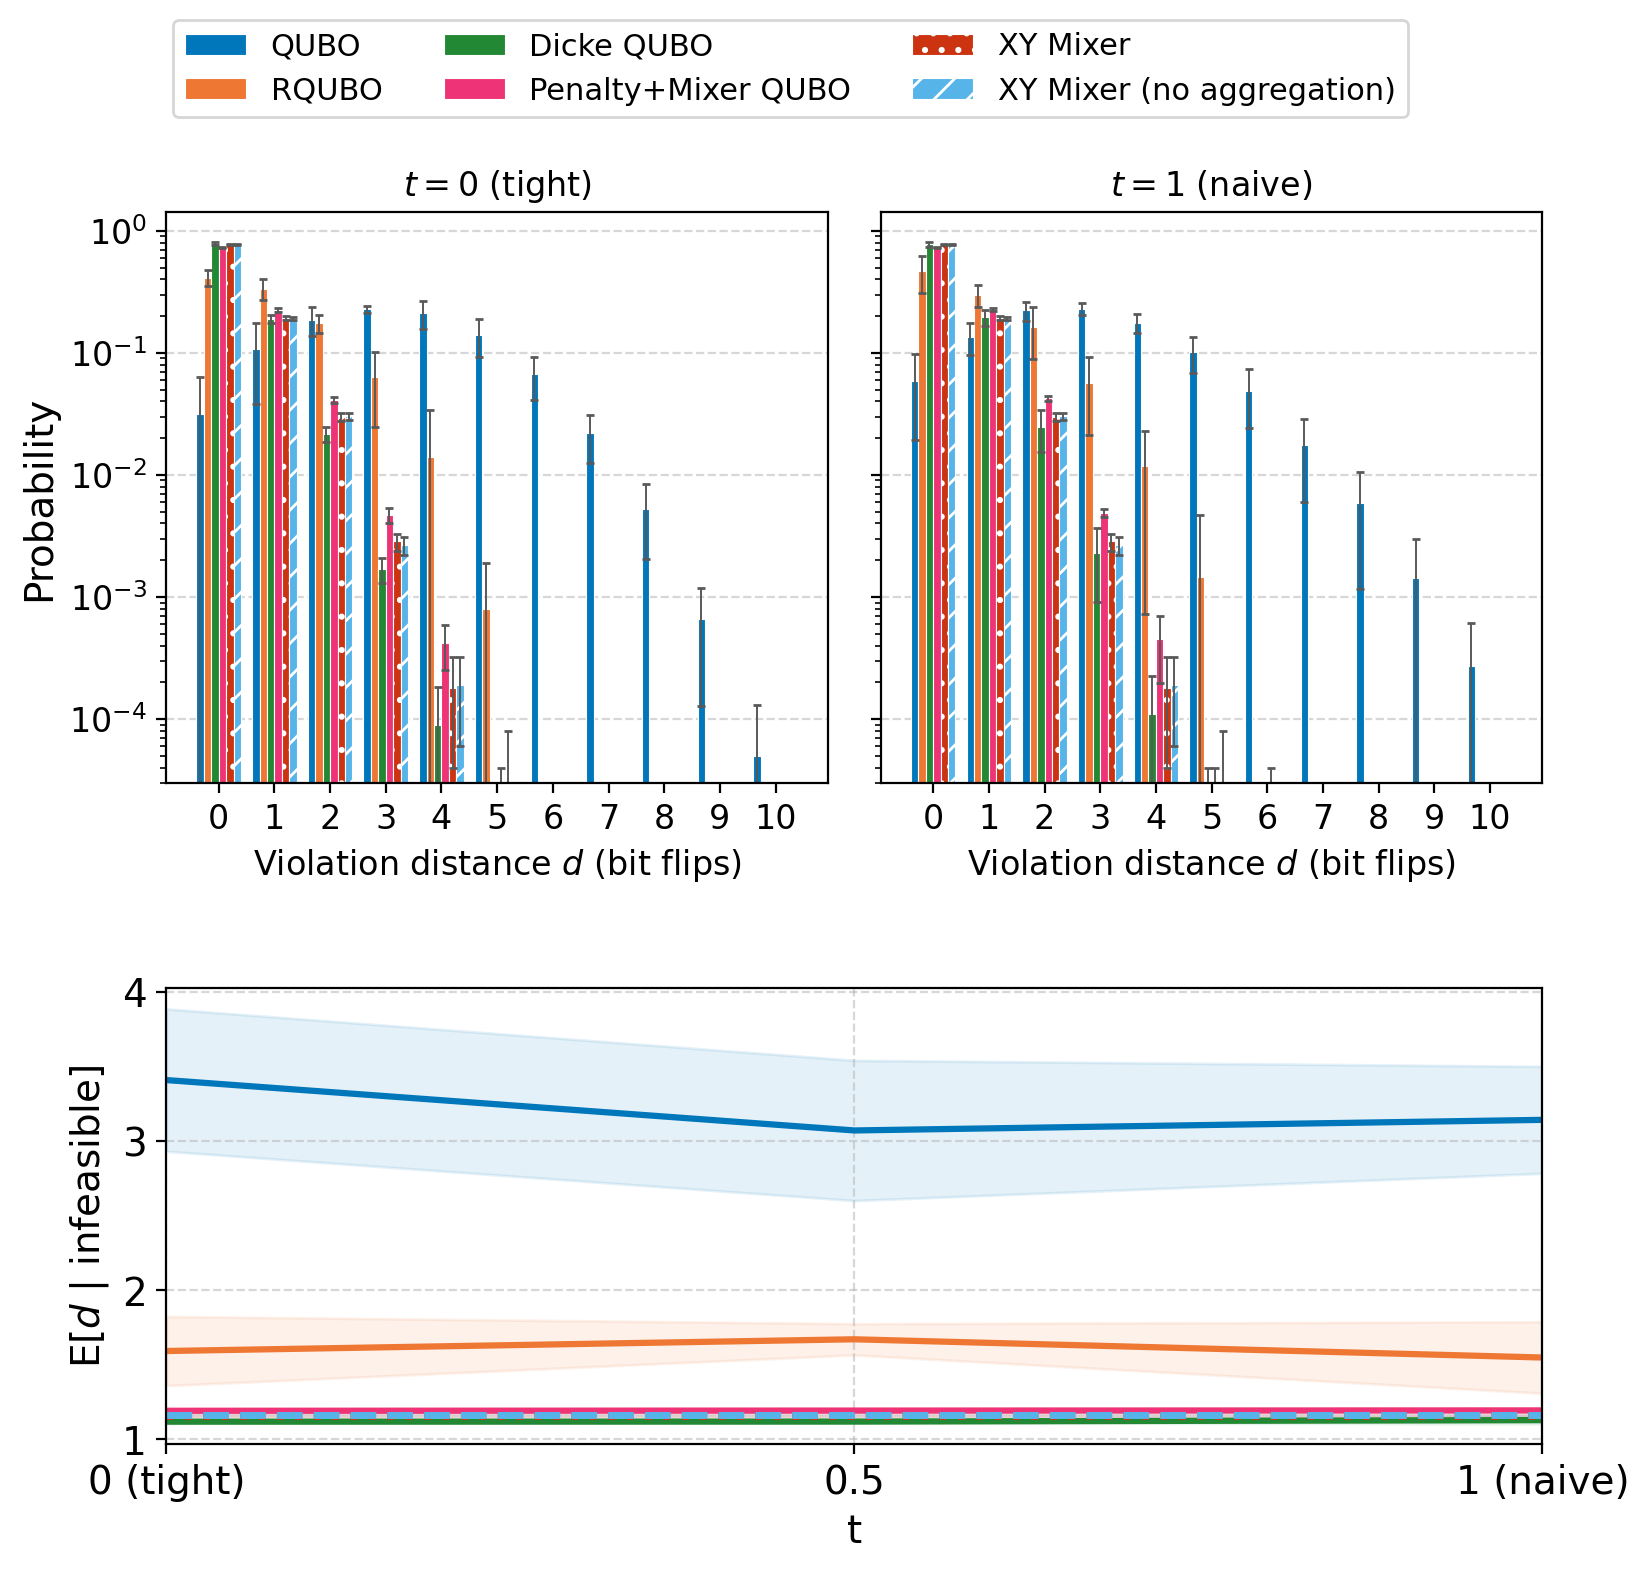

In [11]:
# Constraint-violation distance figure (companion to Figure 6)

if QUBO_VIOLATION_PMF is None:
    print(f"No violation data in {loaded_data_path}; run generate_results.ipynb to produce the *_violations.npz file.")
else:
    import warnings as _warnings

    # Paul Tol vibrant + sky blue (colorblind-safe, higher chroma) -- same as Figure 6
    qubo_color = "#0077BB"
    rqubo_color = "#EE7733"
    dicke_qubo_color = "#228833"
    penalty_mixer_color = "#EE3377"
    xy_mixer_color = "#CC3311"
    xy_no_agg_color = "#56B4E9"

    plt.rcParams["lines.linewidth"] = 2.25
    _fill_alpha = 0.10

    bar_models = [
        ("QUBO", QUBO_VIOLATION_PMF, qubo_color, None),
        ("RQUBO", RQUBO_VIOLATION_PMF, rqubo_color, None),
        ("Dicke QUBO", DICKE_QUBO_VIOLATION_PMF, dicke_qubo_color, None),
        ("Penalty+Mixer QUBO", PENALTY_MIXER_QUBO_VIOLATION_PMF, penalty_mixer_color, None),
        ("XY Mixer", XY_MIXER_VIOLATION_PMF, xy_mixer_color, ".."),
        ("XY Mixer (no aggregation)", XY_MIXER_NO_AGG_VIOLATION_PMF, xy_no_agg_color, "//"),
    ]
    bar_models = [(l, p, c, h) for (l, p, c, h) in bar_models if p is not None]

    # Show distances up to the largest with any mass (mean over graphs), at least 4
    max_shown = 4
    for _, pmf, _, _ in bar_models:
        mean_pmf = pmf.mean(axis=0)  # (num_pens, D+1) or (D+1,)
        nonzero = np.nonzero(np.atleast_2d(mean_pmf).max(axis=0) > 0)[0]
        if nonzero.size:
            max_shown = max(max_shown, int(nonzero.max()))
    dists = np.arange(max_shown + 1)

    fig = plt.figure(figsize=(8, 8))
    gs = fig.add_gridspec(
        2, 2, height_ratios=[1, 0.8], hspace=0.4, wspace=0.08,
        top=0.86, bottom=0.09, left=0.11, right=0.97,
    )
    ax_tight = fig.add_subplot(gs[0, 0])
    ax_naive = fig.add_subplot(gs[0, 1], sharey=ax_tight)
    ax_bottom = fig.add_subplot(gs[1, :])

    n_bars = len(bar_models)
    bar_width = 0.8 / n_bars
    # Floor slightly below one shot out of 10,000 so single-shot mass stays visible on the log scale
    log_floor = 3e-5

    for ax, pen_idx, panel_title in [(ax_tight, 0, "$t = 0$ (tight)"), (ax_naive, -1, "$t = 1$ (naive)")]:
        for m_idx, (label, pmf, color, hatch) in enumerate(bar_models):
            if pmf.ndim == 3:      # penalty-based model: (num_graphs, num_pens, D+1)
                data = pmf[:, pen_idx, : max_shown + 1]
            else:                  # XY mixers: (num_graphs, D+1), independent of t
                data = pmf[:, : max_shown + 1]
            mean = data.mean(axis=0)
            std = data.std(axis=0)
            offsets = dists - 0.4 + bar_width * (m_idx + 0.5)
            # Clip the lower error bar so it stays on the log axis
            yerr_lo = np.minimum(std, np.maximum(mean - log_floor, 0))
            ax.bar(
                offsets, mean, width=bar_width,
                color=color, hatch=hatch, edgecolor="white", linewidth=0.4,
                yerr=[yerr_lo, std], error_kw=dict(elinewidth=0.7, capsize=1.5, ecolor="0.35"),
                label=label if ax is ax_tight else None,
            )
        ax.set_yscale("log")
        ax.set_ylim(bottom=log_floor)
        ax.set_xticks(dists)
        ax.set_xlabel("Violation distance $d$ (bit flips)", fontsize=12)
        ax.set_title(panel_title, fontsize=12)
        ax.grid(True, which="major", axis="y", linestyle="--", alpha=0.5)
        ax.set_axisbelow(True)
        ax.tick_params(axis="x", labelsize=12)
        ax.tick_params(axis="y", labelsize=12)
    ax_tight.set_ylabel("Probability", fontsize=14)
    plt.setp(ax_naive.get_yticklabels(), visible=False)

    # -----------------------------
    # Bottom row: E[d | infeasible] vs t (Figure 6 style)
    # -----------------------------
    line_models = [
        ("QUBO", QUBO_EXP_VIOLATION_INFEAS, qubo_color),
        ("RQUBO", RQUBO_EXP_VIOLATION_INFEAS, rqubo_color),
        ("Dicke QUBO", DICKE_QUBO_EXP_VIOLATION_INFEAS, dicke_qubo_color),
        ("Penalty+Mixer QUBO", PENALTY_MIXER_QUBO_EXP_VIOLATION_INFEAS, penalty_mixer_color),
    ]
    with _warnings.catch_warnings():
        # A fully feasible run has no infeasible samples -> all-NaN slice; nanmean warns
        _warnings.simplefilter("ignore", category=RuntimeWarning)
        for label, vals, color in line_models:
            if vals is None:
                continue
            mean = np.nanmean(vals, axis=0)
            std = np.nanstd(vals, axis=0)
            ax_bottom.plot(penalty_list, mean, color=color, linestyle='-')
            ax_bottom.fill_between(penalty_list, mean - std, mean + std, color=color, alpha=_fill_alpha)

        if XY_MIXER_EXP_VIOLATION_INFEAS is not None:
            xy_mean = np.nanmean(XY_MIXER_EXP_VIOLATION_INFEAS)
            xy_std = np.nanstd(XY_MIXER_EXP_VIOLATION_INFEAS)
            if np.isfinite(xy_mean):
                ax_bottom.axhline(y=xy_mean, color=xy_mixer_color, linestyle=':', linewidth=2.5)
                ax_bottom.axhspan(xy_mean - xy_std, xy_mean + xy_std, color=xy_mixer_color, alpha=0.12)

        if XY_MIXER_NO_AGG_EXP_VIOLATION_INFEAS is not None:
            xyna_mean = np.nanmean(XY_MIXER_NO_AGG_EXP_VIOLATION_INFEAS)
            xyna_std = np.nanstd(XY_MIXER_NO_AGG_EXP_VIOLATION_INFEAS)
            if np.isfinite(xyna_mean):
                ax_bottom.axhline(y=xyna_mean, color=xy_no_agg_color, linestyle='--', linewidth=2.5)
                ax_bottom.axhspan(xyna_mean - xyna_std, xyna_mean + xyna_std, color=xy_no_agg_color, alpha=0.08)

    ax_bottom.grid(True, which='both', linestyle='--', alpha=0.5)
    ax_bottom.set_xlim(0, 1)
    ax_bottom.set_xlabel('t', fontsize=14)
    ax_bottom.set_xticks([0, 0.5, 1])
    ax_bottom.set_xticklabels(["0 (tight)", "0.5", "1 (naive)"], fontsize=12)
    ax_bottom.set_ylabel('E[$d$ | infeasible]', fontsize=14)
    ax_bottom.tick_params(axis='x', labelsize=14)
    ax_bottom.tick_params(axis='y', labelsize=14)

    handles, labels = ax_tight.get_legend_handles_labels()
    _leg = fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        bbox_transform=fig.transFigure,
        ncol=3,
        fontsize=11,
        frameon=True,
    )
    _leg.set_clip_on(False)

    data_tag = os.path.splitext(os.path.basename(loaded_data_path))[0]
    fig.savefig(
        os.path.join("Data", f"violation_distance_{data_tag}.pdf"),
        bbox_inches="tight",
        pad_inches=0.2,
        bbox_extra_artists=[_leg],
    )